# 01 — Data Preparation

**역할**: Minari Ant `mujoco/ant/expert-v0` dataset에서 phase-coherent demonstration을 추출 → train/val split → train-only normalization stats 저장.

**산출물**: `data/demos_ant.npz`, `data/norm_stats.npz`, `figures/data_*.png`

---

이 노트북은 **실행 orchestration만 담당**합니다. 핵심 로직은 `pcdp/data_extraction.py`(Minari load + Hilbert phase + quality filter), `pcdp/data_pipeline.py`(train/val split + normalization stats), artifact 경로 관리는 `pcdp/paths.py`에 있습니다.

In [1]:
# Google Drive mount and project-root setup for Colab
from pathlib import Path
import os

PROJECT_DIR = Path('/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy')

try:
    from google.colab import drive
except ImportError:
    print(f'Not running in Google Colab; keeping current working directory: {Path.cwd()}')
else:
    drive.mount('/content/drive')
    if not PROJECT_DIR.exists():
        raise FileNotFoundError(
            f'Expected project directory not found: {PROJECT_DIR}\n'
            'Update PROJECT_DIR to the Google Drive folder that contains this repository.'
        )
    os.chdir(PROJECT_DIR)
    print(f'Current working directory: {Path.cwd()}')


Mounted at /content/drive
Current working directory: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy


In [2]:
# Colab dependency setup
import importlib.util
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec("google.colab") is None:
    print("Not running in Google Colab; skipping dependency installation and using the current environment.")
else:
    project_root = Path.cwd()
    requirements_path = project_root / "requirements.txt"
    install_command = [sys.executable, "-m", "pip", "install"]

    if requirements_path.exists():
        # requirements.txt pins the runtime stack; -e . installs this repo from pyproject.toml.
        install_command.extend(["-r", str(requirements_path), "-e", str(project_root)])
    else:
        # Fallback to pyproject.toml dependencies if requirements.txt is unavailable.
        install_command.extend(["-e", str(project_root)])

    subprocess.check_call(install_command)

    import gymnasium as gym
    import mujoco
    import minari
    import torch

    gym.make("Ant-v5").close()

    print(f"gymnasium={gym.__version__}")
    print(f"mujoco={mujoco.__version__}")
    print(f"minari={minari.__version__}")
    print(f"torch={torch.__version__}")
    print("Ant-v5 environment smoke check passed.")


gymnasium=1.3.0
mujoco=3.9.0
minari=0.5.3
torch=2.11.0+cu128
Ant-v5 environment smoke check passed.


## 1. Artifact paths


In [3]:
from pcdp.paths import ARTIFACT_ROOT, DATA_DIR, FIGURES_DIR, ensure_artifact_dirs
ensure_artifact_dirs()
print(f'✓ artifact root: {ARTIFACT_ROOT}')


✓ artifact root: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts


## 2. Dataset discovery and load

In [4]:
import minari
import numpy as np

from pcdp.data_extraction import (
    ANT_PHASE_JOINT_IDX,
    DEFAULT_MINARI_ANT_DATASET,
    DemoExtractionConfig,
    extract_demos_from_episodes,
    load_ant_dataset,
    materialize_episodes,
    plot_demo_quality,
    print_demo_quality_report,
    save_demos,
)

print(f'Minari version: {minari.__version__}')
dataset = load_ant_dataset(minari, DEFAULT_MINARI_ANT_DATASET)


Minari version: 0.5.3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


namespace_metadata.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

metadata.json:   0%|          | 0.00/3.43k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/1.68k [00:00<?, ?B/s]

...

namespace_metadata.json:   0%|          | 0.00/267 [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

namespace_metadata.json:   0%|          | 0.00/105 [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset mujoco/ant/expert-v0 downloaded to /root/.minari/datasets/mujoco/ant/expert-v0
=== Loaded: mujoco/ant/expert-v0 ===
Total episodes: 2026
Total steps: 2000000
Observation space: Box(-inf, inf, (105,), float64)
Action space: Box(-1.0, 1.0, (8,), float32)


## 3. Episode diagnostics

In [5]:
config = DemoExtractionConfig()
episodes = materialize_episodes(dataset, expected_obs_dim=config.expected_obs_dim)
print(f'Phase 라벨링용 joint: obs[{ANT_PHASE_JOINT_IDX}]')


Total episodes loaded: 2026
Episode length sample: min=802, mean=998, max=1000
Phase 라벨링용 joint: obs[19]


## 4. Demo extraction and `demos_ant.npz` save

In [6]:
demos = extract_demos_from_episodes(episodes, config)
assert demos is not None, '선택된 demos가 없습니다. DemoExtractionConfig 임계값을 완화해 주세요.'
demos_path = save_demos(demos, DATA_DIR / 'demos_ant.npz')


Phase 1: episodes 처리 (max 5000) [method=hilbert]
  처리됨: 495 (too short: 5)
  처리됨: 993 (too short: 7)
  처리됨: 1489 (too short: 11)
  처리됨: 1983 (too short: 17)

총 처리: 2009 episodes (too short: 17)

Phase 2: Quality 분포 (전체 2009 eps)
  mono:      min=0.83, mean=1.00, max=1.00
  sharp:     min=3.80, mean=6.40, max=11.57
  freq_stab: min=0.26, mean=0.52, max=1.27
  freq:      min=1.60, mean=2.06, max=2.70

Phase 3: 주기성 필터
  mono >= 0.9, sharp >= 8.0, stab <= 0.5
  통과: 150/2009 (7.5%)

Phase 4: Quality 기준 top-120 선택

=== 선택된 120 demos 특성 ===
  freq:  mean=2.023, std=0.102, range=[1.800, 2.300] Hz
  mono:  mean=0.999, min=0.985
  sharp: mean=9.056, min=8.169

  In-distribution window (mean±2σ): [1.819, 2.228] Hz

✓ 저장: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/data/demos_ant.npz (120 episodes)
  학습 freq window: 2.023 ± 0.102 Hz (range [1.800, 2.300])


## 5. Quality plots and report

Loaded: ['observations', 'actions', 'phases', 'episode_lengths', 'estimated_freqs', 'monotonicity', 'peak_sharpness', 'freq_stability', 'freq_window_mean', 'freq_window_std', 'freq_window_min', 'freq_window_max']
Episodes: 120
평균 length: 200.0
✓ 저장: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/data_quality_distribution.png


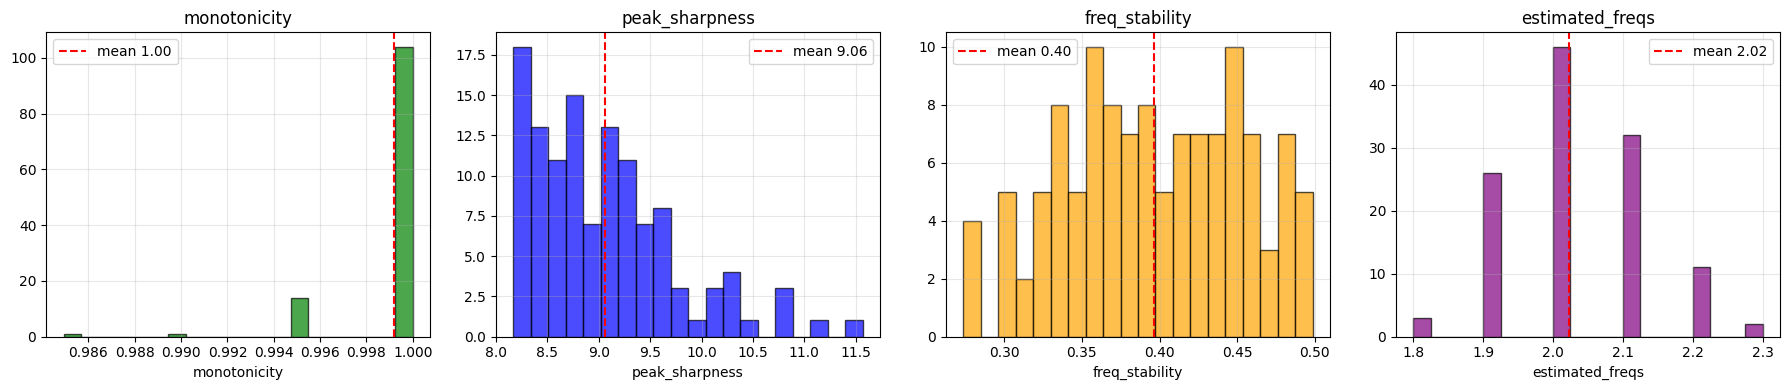

✓ 저장: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/data_demo_examples.png


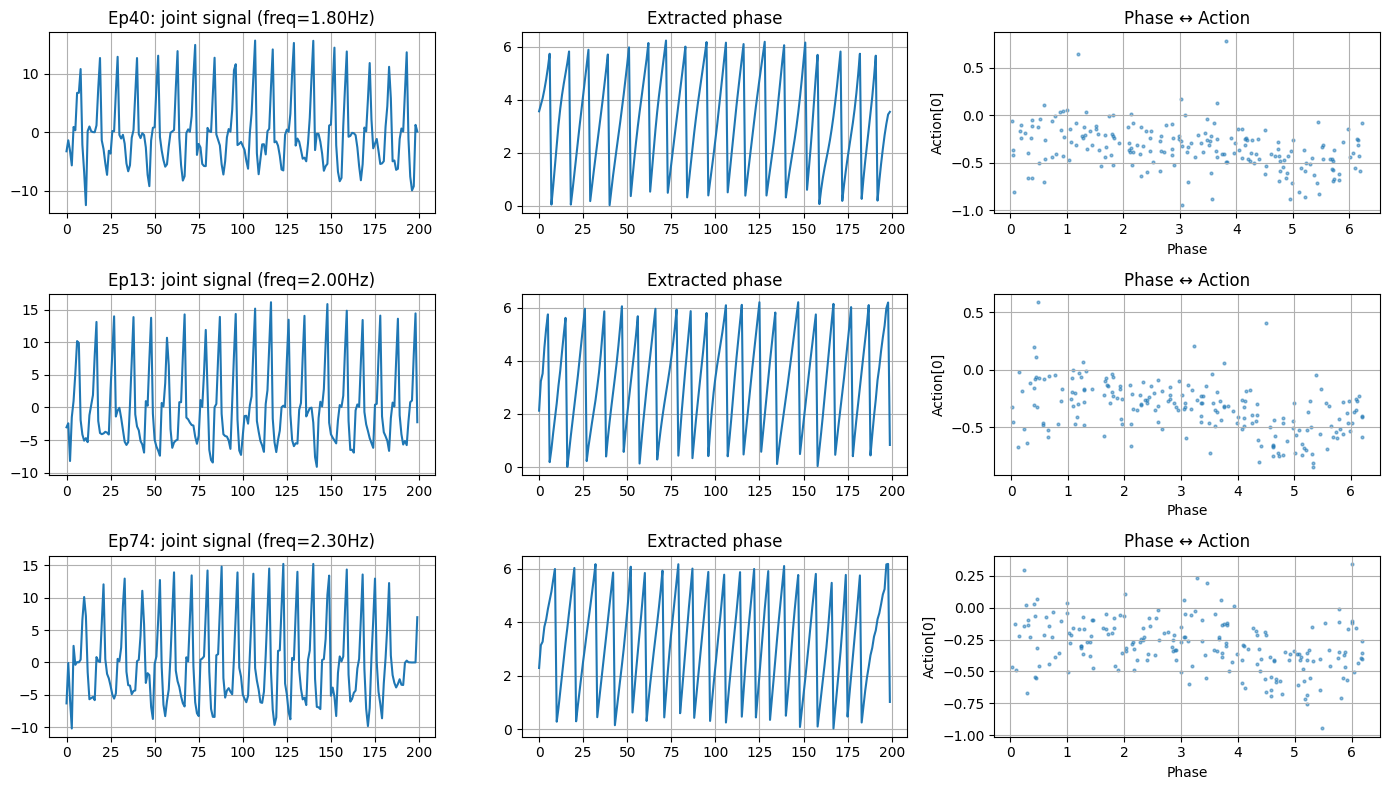

=== Demo 품질 자동 평가 ===

1. Episode 수: 120
   ✓ 충분 (50+)

2. 평균 length: 200.0
   ✓ 우수

3. 평균 phase quality: mono=1.00, sharp=9.06
   ✓ 매우 깔끔


In [7]:
demos_loaded = np.load(demos_path)
quality_path, visualization_path = plot_demo_quality(demos_loaded, FIGURES_DIR)
print_demo_quality_report(demos_loaded)


## 6. Data pipeline — split + normalization

Phase 1에서 만든 `demos_ant.npz`를 episode-level train/val split하고, train-only normalization stats와 horizon/frequency 메타데이터를 `norm_stats.npz`로 저장합니다.

In [8]:
from pcdp.data_pipeline import DataPipelineConfig, plot_phase_advance, run_data_pipeline

DATA_PATH = DATA_DIR / 'demos_ant.npz'
NORM_PATH = DATA_DIR / 'norm_stats.npz'
assert DATA_PATH.exists(), f'파일 없음: {DATA_PATH}'

pipeline_cfg = DataPipelineConfig(
    obs_horizon=2,
    pred_horizon=16,
    action_horizon=8,
    val_ratio=0.15,
    batch_size=256,
    num_workers=2,
    seed=42,
)
pipeline = run_data_pipeline(DATA_PATH, NORM_PATH, pipeline_cfg)
train_dataset = pipeline['train_dataset']
val_dataset = pipeline['val_dataset']
train_loader = pipeline['train_loader']
val_loader = pipeline['val_loader']


✓ 저장: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/data/norm_stats.npz
  파일 크기: 5.6 KB


## 6. Phase-advance diagnostic

Phase 진행률 (rad/step):
  관측: mean=0.6312, std=0.0667
  이론: 2π × 2.023 × 0.05 = 0.6356
  비율: 0.993× (1.0에 가까울수록 일관)


/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/pcdp/data_pipeline.py:261: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/pcdp/data_pipeline.py:261: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/pcdp/data_pipeline.py:261: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/pcdp/data_pipeline.py:261: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/pcdp/data_pipeline.py:261: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/drive/MyD

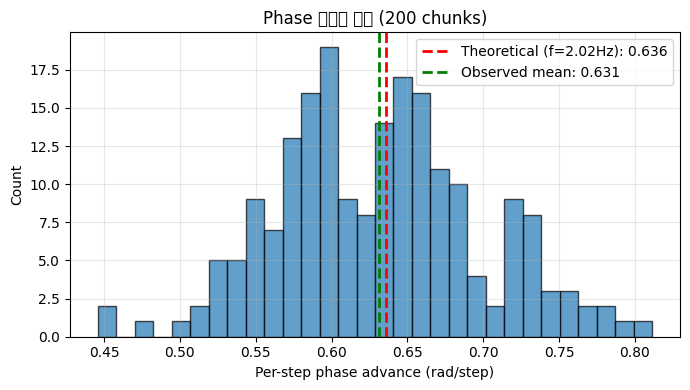


✓ 저장: /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/data_phase_advance.png

=== 01 Data Preparation 완료 ===
Demos:        /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/data/demos_ant.npz
Norm stats:   /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/data/norm_stats.npz
Train chunks: 18768
Val chunks:   3312
Steps/epoch:  73
Phase plot:   /content/drive/MyDrive/2026/phase_conditioned_diffusion_policy/artifacts/figures/data_phase_advance.png


In [9]:
phase_advance = plot_phase_advance(
    train_dataset,
    FIGURES_DIR,
    f_mean=pipeline['project_data']['freq_window_mean'],
    seed=pipeline_cfg.seed,
)
print('\n=== 01 Data Preparation 완료 ===')
print(f'Demos:        {demos_path}')
print(f'Norm stats:   {NORM_PATH}')
print(f'Train chunks: {len(train_dataset)}')
print(f'Val chunks:   {len(val_dataset)}')
print(f'Steps/epoch:  {len(train_loader)}')
print(f'Phase plot:   {phase_advance["path"]}')
